In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv(
    "../data/processed/oil_well_clean.csv",
    index_col="date",
    parse_dates=True
)

df.head()

,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
date,,,,,,,,
2013-01-01,49.0,70.0,13055.0,21.0,29.0,24.0,1819.0,214.0
2013-01-02,49.0,70.0,13055.0,21.0,29.0,24.0,1836.0,214.0
2013-01-03,49.0,70.0,13055.0,21.0,29.0,24.0,1788.0,214.0
2013-01-04,49.0,70.0,13055.0,21.0,29.0,24.0,1789.0,214.0
2013-01-05,44.0,70.0,11768.0,26.0,36.0,24.0,1825.0,214.0


In [18]:
df.shape

(2940, 8)

In [19]:
df.describe()

,oil_volume,liquid_volume,gas_volume,water_volume,water_cut,working_hours,dynamic_level,reservoir_pressure
count,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000,2940.000000
mean,17.626701,59.467687,4730.789626,41.830102,70.692517,22.344218,1930.387755,157.026871
std,9.688208,18.631944,2598.680466,13.054579,9.533381,3.039137,114.524500,32.914279
min,0.000000,12.000000,4.000000,9.000000,29.000000,7.000000,1529.000000,100.000000
25%,11.000000,50.000000,3042.250000,33.000000,69.000000,22.000000,1855.000000,129.000000
50%,15.000000,58.000000,3910.500000,43.000000,73.000000,24.000000,1890.000000,157.000000
75%,22.000000,74.000000,5844.000000,50.000000,76.000000,24.000000,2008.000000,185.250000
max,49.000000,113.000000,13113.000000,99.000000,100.000000,24.000000,2137.000000,214.000000


In [25]:
df.index.min(), df.index.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2021-01-18 00:00:00'))

In [26]:
df.index.to_series().diff().value_counts()

date
1 days    2939
Name: count, dtype: int64

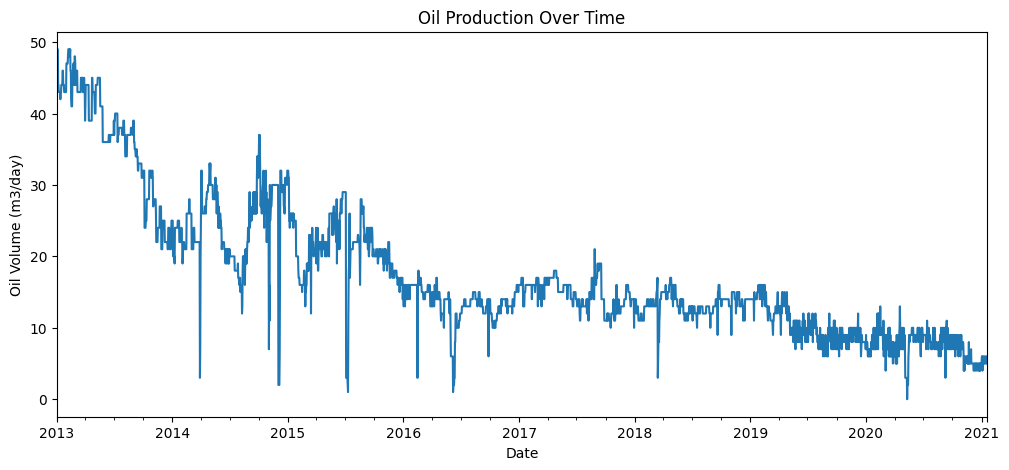

In [27]:
df["oil_volume"].plot(figsize=(12,5), title="Oil Production Over Time")
plt.ylabel("Oil Volume (m3/day)")
plt.xlabel("Date")
plt.savefig("../outputs/figures/oil_production.png")
plt.show()

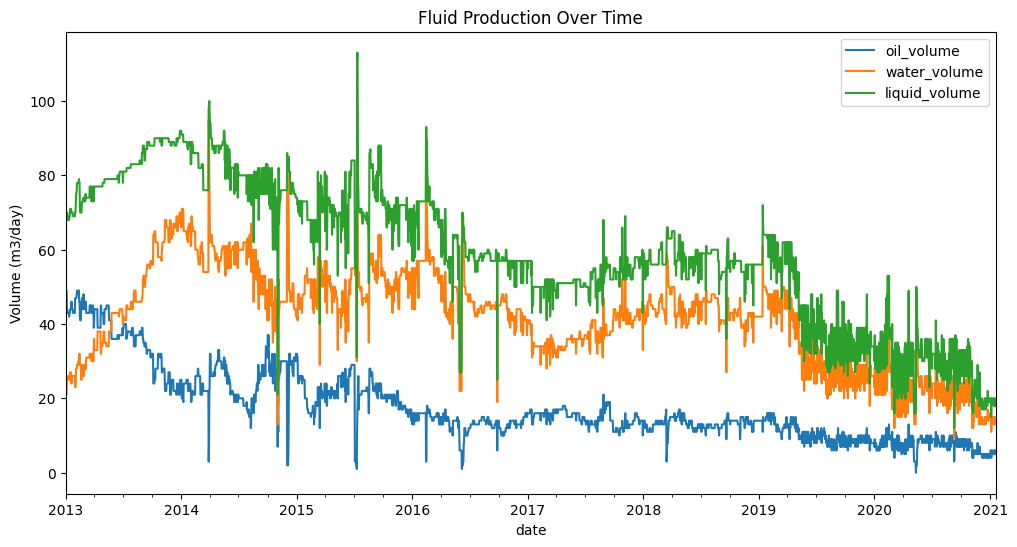

In [29]:
df[["oil_volume","water_volume","liquid_volume"]].plot(figsize=(12,6))
plt.title("Fluid Production Over Time")
plt.ylabel("Volume (m3/day)")
plt.savefig("../outputs/figures/fluid_production.png")
plt.show()

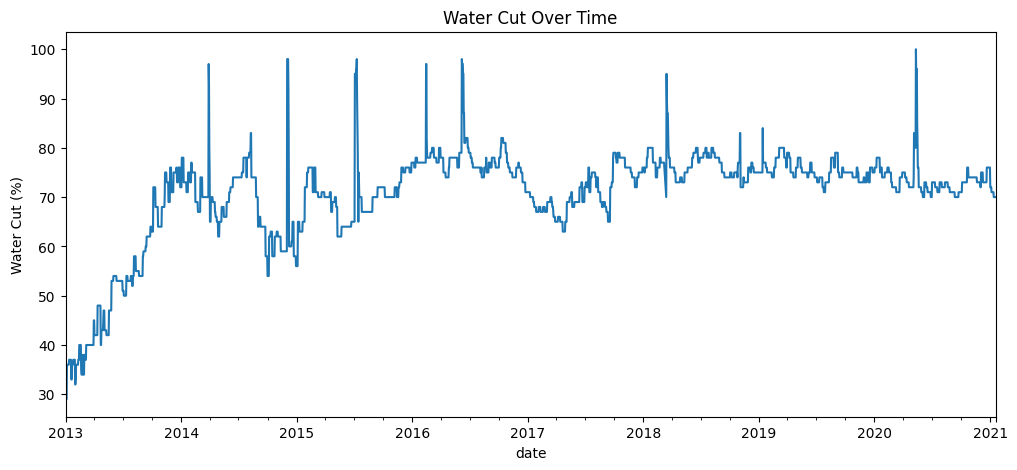

In [31]:
df["water_cut"].plot(figsize=(12,5))
plt.title("Water Cut Over Time")
plt.ylabel("Water Cut (%)")
plt.savefig("../outputs/figures/water_cut.png")
plt.show()

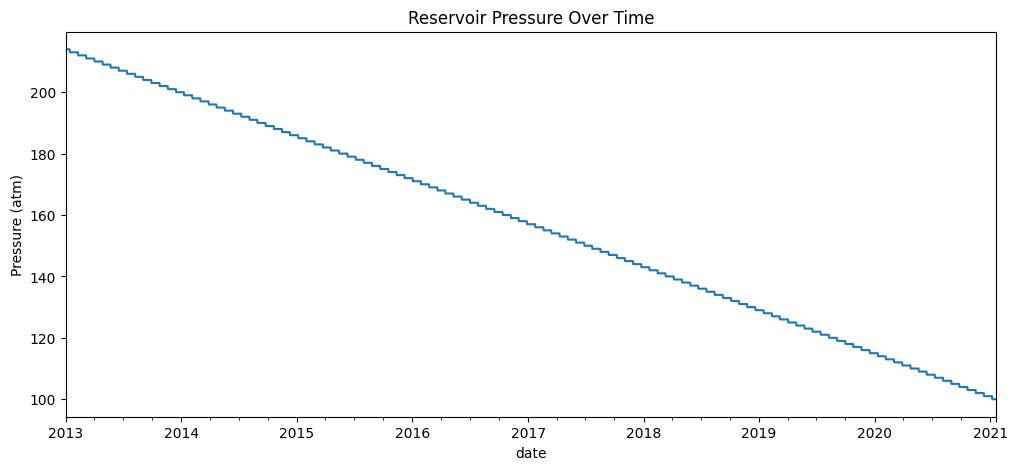

In [ ]:
df["reservoir_pressure"].plot(figsize=(12,5))
plt.title("Reservoir Pressure Over Time")
plt.ylabel("Pressure (atm)")
plt.savefig("../outputs/figures/reservoir_pressure.png")
plt.show()

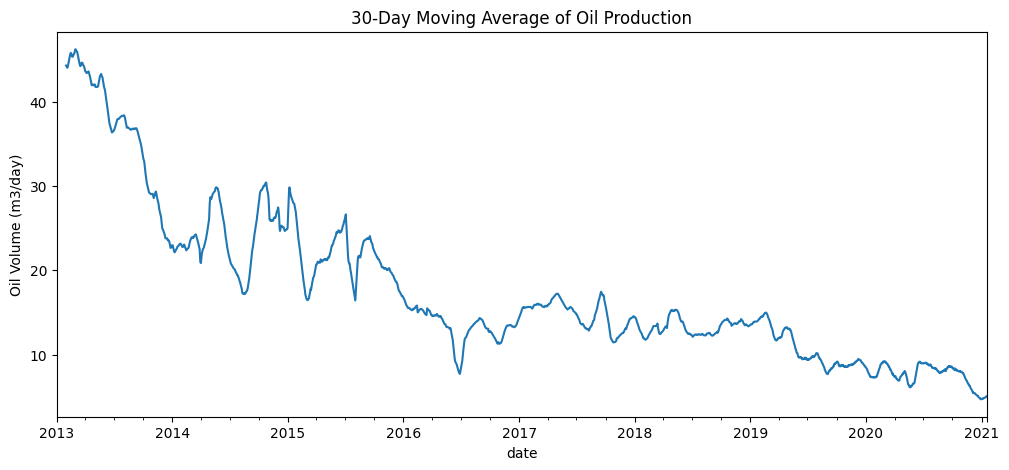

In [35]:
df["oil_volume"].rolling(30).mean().plot(figsize=(12,5))
plt.title("30-Day Moving Average of Oil Production")
plt.ylabel("Oil Volume (m3/day)")
plt.savefig("../outputs/figures/30days_average_oil_production.png")
plt.show()

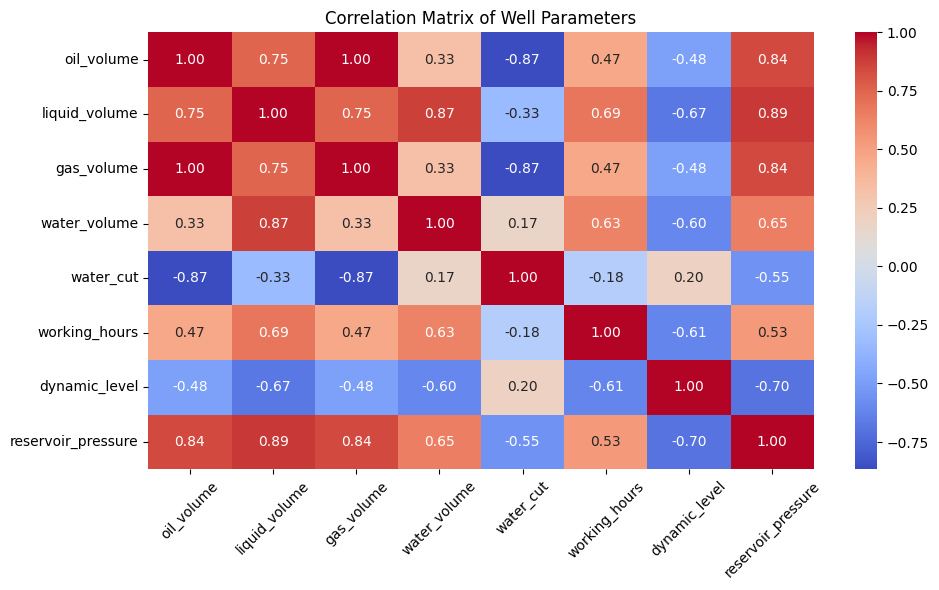

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Well Parameters")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_matrix.png")
plt.show()

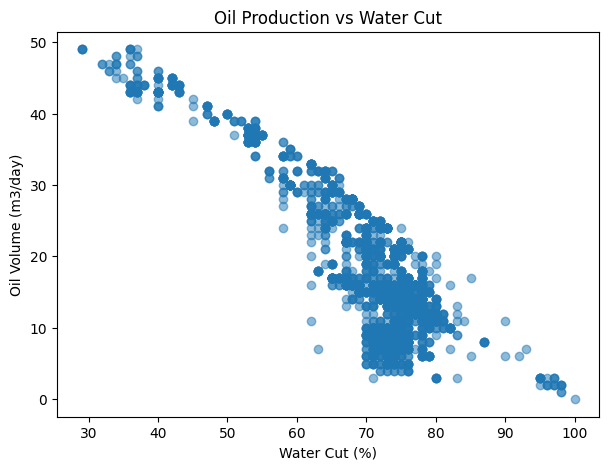

In [40]:
plt.figure(figsize=(7,5))
plt.scatter(df["water_cut"], df["oil_volume"], alpha=0.5)
plt.xlabel("Water Cut (%)")
plt.ylabel("Oil Volume (m3/day)")
plt.title("Oil Production vs Water Cut")
plt.savefig("../outputs/figures/oil_production_vs_water_cut.png")
plt.show()

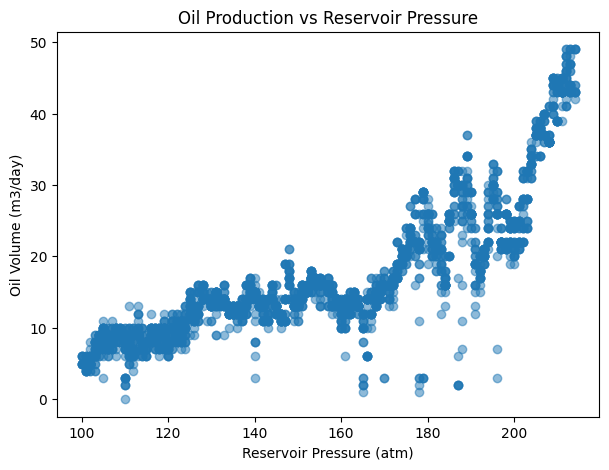

In [43]:
plt.figure(figsize=(7,5))
plt.scatter(df["reservoir_pressure"], df["oil_volume"], alpha=0.5)
plt.xlabel("Reservoir Pressure (atm)")
plt.ylabel("Oil Volume (m3/day)")
plt.title("Oil Production vs Reservoir Pressure")
plt.savefig("../outputs/figures/oil_production_vs_reservoir_pressure.png")
plt.show()

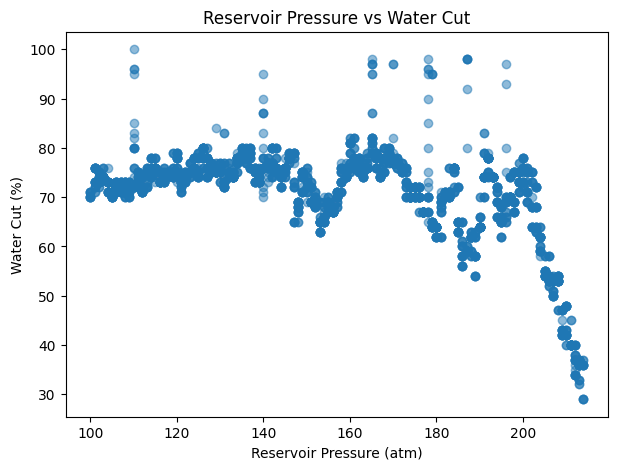

In [46]:
plt.figure(figsize=(7,5))
plt.scatter(df["reservoir_pressure"], df["water_cut"], alpha=0.5)
plt.xlabel("Reservoir Pressure (atm)")
plt.ylabel("Water Cut (%)")
plt.title("Reservoir Pressure vs Water Cut")
plt.savefig("../outputs/figures/reservoir_pressure_vs_water_cut.png")
plt.show()

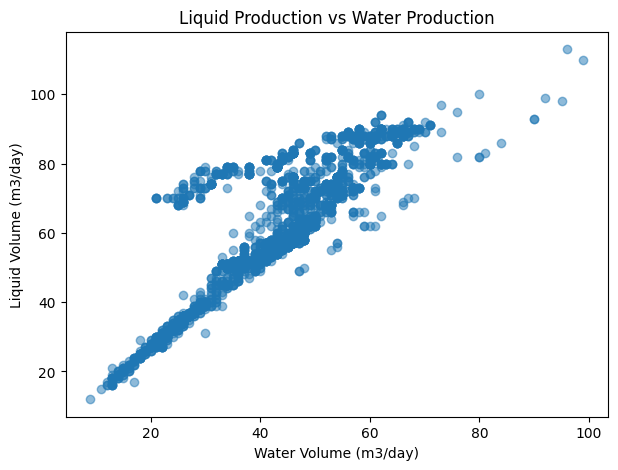

In [51]:
plt.figure(figsize=(7,5))
plt.scatter(df["water_volume"], df["liquid_volume"], alpha=0.5)
plt.xlabel("Water Volume (m3/day)")
plt.ylabel("Liquid Volume (m3/day)")
plt.title("Liquid Production vs Water Production")
plt.savefig("../outputs/figures/liquid_production_vs_water_production.png")
plt.show()

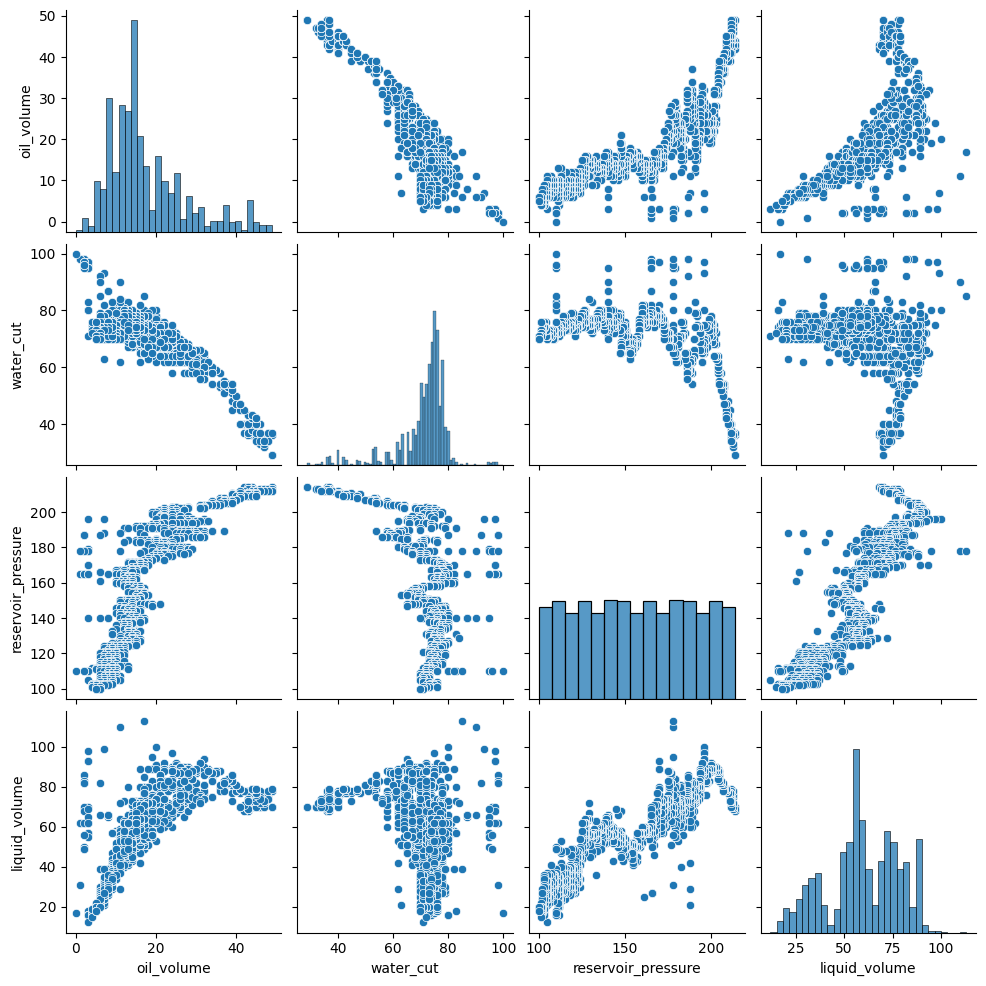

In [47]:
sns.pairplot(
    df[["oil_volume","water_cut","reservoir_pressure","liquid_volume"]]
)
plt.savefig("../outputs/figures/pair_plots_global.png")
plt.show()